In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import lightgbm as lgb
import geopandas as gpd
import optuna

from shapely.geometry import Point
from scipy.optimize import minimize
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from math import radians, sin, cos, sqrt, atan2
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
from scipy.spatial import cKDTree
from sklearn.cluster import KMeans

from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0


In [2]:
# 1. Load raw files
full = pd.read_csv('../data/train_full_sorted.csv', parse_dates=['datetime'])
env = pd.read_csv('../data/data_pendukung/data_lingkungan.csv', parse_dates=['datetime'])
koor = pd.read_csv('../data/data_pendukung/koordinat_pos.csv')
    
cutoff = pd.Timestamp('2025-09-19')
full['is_train'] = (full['datetime'] < cutoff).astype(int)

print(full.head())
print('train range:', full.loc[full['is_train'] == 1, 'datetime'].min(), '-', full.loc[full['is_train'] == 1, 'datetime'].max())
print('val range:', full.loc[full['is_train'] == 0, 'datetime'].min(), '-', full.loc[full['is_train'] == 0, 'datetime'].max())

             datetime                nama_pos  tma_mdpl  is_train
0 2023-01-01 06:00:00  Arjowinangun - Pacitan      1.30         1
1 2023-01-01 12:00:00  Arjowinangun - Pacitan      1.20         1
2 2023-01-01 18:00:00  Arjowinangun - Pacitan      1.50         1
3 2023-01-02 06:00:00  Arjowinangun - Pacitan      1.45         1
4 2023-01-02 12:00:00  Arjowinangun - Pacitan      1.25         1
train range: 2023-01-01 06:00:00 - 2025-09-18 18:00:00
val range: 2025-09-19 06:00:00 - 2026-05-18 18:00:00


In [3]:
numeric_cols = env.select_dtypes(include='number').columns
for col in numeric_cols:
    n_sentinel = (env[col] == -999).sum()
    if n_sentinel > 0:
        print(f'{col}: {n_sentinel} baris sentinel -999 -> diubah jadi NaN')
        env[col] = env[col].replace(-999, np.nan)

# === LANGKAH LAMA: assign window_end (tidak berubah) ===
hour = env['datetime'].dt.hour
date = env['datetime'].dt.normalize()
conditions = [hour < 6, hour < 12, hour < 18]
choices = [date + pd.Timedelta(hours=6), date + pd.Timedelta(hours=12), date + pd.Timedelta(hours=18)]
default = date + pd.Timedelta(days=1, hours=6)
env['window_end'] = np.select(conditions, choices, default=default)

# === LANGKAH LAMA: agregasi (tidak berubah, tapi hasilnya sekarang aman krn NaN otomatis di-skip oleh sum/mean) ===
agg_dict = {
    'rainfall_mm': 'sum', 'rainfall_openmeteo_mm': 'sum', 'rainfall_max_24h_mm': 'max',
    'humidity_pct': 'mean', 'wind_direction_deg': 'mean', 'dew_point_c': 'mean',
    'cloud_cover_pct': 'mean', 'temperature_c': 'mean', 'wind_speed_kmh': 'mean',
    'solar_radiation_mj_m2': 'sum', 'soil_moisture_0_7cm': 'mean', 'soil_moisture_7_28cm': 'mean',
    'soil_moisture_28_100cm': 'mean', 'soil_moisture_100_255cm': 'mean',
    'surface_pressure_hpa': 'mean', 'pressure_msl_hpa': 'mean', 'built_surface_m2': 'first',
    'landcover_class': 'first', 'landcover_name': 'first', 'rmm1': 'mean', 'rmm2': 'mean',
    'mjo_phase': 'first', 'mjo_amplitude': 'mean', 'mjo_active': 'first', 'nino_34': 'mean',
}
env_agg = env.groupby(['nama_pos', 'window_end']).agg(agg_dict).reset_index()

sum_cols = ['rainfall_mm', 'rainfall_openmeteo_mm', 'solar_radiation_mj_m2']

for col in sum_cols:
    all_nan_mask = env.groupby(['nama_pos', 'window_end'])[col].apply(lambda x: x.isna().all())
    n_affected = all_nan_mask.sum()
    print(f'{col}: {n_affected} window full-NaN -> override balik jadi NaN')
    # all_nan_mask index-nya sama (nama_pos, window_end) dgn env_agg, jadi bisa langsung dipakai buat masking
    env_agg.loc[all_nan_mask.values, col] = np.nan
    
env_agg = env_agg.rename(columns={'window_end': 'datetime'})

full = full.merge(env_agg, on=['nama_pos', 'datetime'], how='left')

# === CEK HASIL ===
print(full['solar_radiation_mj_m2'].describe())   # min sekarang harusnya wajar, tidak lagi -11988
print(full[full['datetime'] >= '2025-12-31'][['solar_radiation_mj_m2','soil_moisture_0_7cm','nino_34']].isna().sum())

solar_radiation_mj_m2: 100080 baris sentinel -999 -> diubah jadi NaN
rainfall_mm: 0 window full-NaN -> override balik jadi NaN
rainfall_openmeteo_mm: 0 window full-NaN -> override balik jadi NaN
solar_radiation_mj_m2: 12510 window full-NaN -> override balik jadi NaN
count    93696.000000
mean      1719.582734
std       1338.502936
min          0.000000
25%         14.120000
50%       2084.360000
75%       2836.980000
max       4387.940000
Name: solar_radiation_mj_m2, dtype: float64
solar_radiation_mj_m2    12480
soil_moisture_0_7cm         60
nino_34                   1590
dtype: int64


In [4]:
full.to_csv("../data/outputt.csv", index=False)

In [5]:
full.drop([
    "rainfall_openmeteo_mm", # korelasi = 1
], axis=1, inplace=True)

In [6]:
def detect_and_fix_glitches(df, window=4, ratio_threshold=4, zscore_threshold=10, min_abs_jump=1.0):
    df = df.sort_values(['nama_pos','datetime'])  # TANPA reset_index (biar index tetap nyambung ke full)
    glitch_indices = []
    for pos, g in df.groupby('nama_pos'):
        val = g['tma_mdpl'].values
        idx_list = g.index.tolist()
        local_std = np.std(val)
        for i in range(window, len(val)-window):
            neighborhood = np.concatenate([val[i-window:i], val[i+1:i+1+window]])
            local_median = np.median(neighborhood)
            cur_v = val[i]
            jump = abs(cur_v - local_median)
            if jump < min_abs_jump:
                continue
            ratio = max(cur_v/local_median, local_median/cur_v) if cur_v>0 and local_median>0 else 999
            is_extreme = (ratio > ratio_threshold) or (local_std > 0 and (jump/local_std) > zscore_threshold)
            if is_extreme:
                glitch_indices.append(idx_list[i])
    print(f'Ditemukan {len(glitch_indices)} titik glitch')
    df.loc[glitch_indices, 'tma_mdpl'] = np.nan
    df['tma_mdpl'] = df.groupby('nama_pos')['tma_mdpl'].transform(lambda x: x.interpolate(method='linear'))
    return df, glitch_indices

train_part = full[full['datetime'] < '2025-09-19'].copy()
train_part_fixed, glitch_idx = detect_and_fix_glitches(train_part)
full.loc[train_part_fixed.index, 'tma_mdpl'] = train_part_fixed['tma_mdpl']

Ditemukan 24 titik glitch


In [7]:
pairs = [
    ('Bengkelolor','Boboh Kali Lamong',1.6), ('Brangkal','Bojonegoro - Kali Kethek',5.4),
    ('Gunungsari','Arjowinangun - Pacitan',6.7), ('Jarum','Serenan',7.8),
    ('Kali Pepe - Tugu Boto','Kali Anyar - Kreteg Abang',8.3), ('Ketonggo','Napel',8.8),
    ('Ngadipiro','Wonogiri Dam',10.8), ('Karangnongko','Cepu',18.8), ('Colo Weir','Serenan',19.5),
    ('Napel','Karangnongko',23.8), ('Sumberrejo','Babat',24.0), ('Floodway Bridge C','Karanggeneng',26.8),
    ('Ngrembang','Wonogiri Dam',26.9), ('Kali Anyar - Kreteg Abang','Kedungupit',28.0),
    ('Wonogiri Dam','Serenan',30.1), ('Jurug','Kedungupit',30.2), ('Kedungupit','Kajangan',31.8),
    ('Kali Pepe - PTPN','Kedungupit',32.8), ('Kajangan','Napel',34.9), ('Peren','Kedungupit',43.2),
    ('Serenan','Kedungupit',44.7), ('Babat','Karanggeneng',48.1), ('Bojonegoro - Kali Kethek','Babat',51.7),
    ('Cepu','Bojonegoro - Kali Kethek',59.5), ('Sekayu','Napel',66.9), ('Badegan','Napel',79.0),
]

velocity_kmh = 3.6  # asumsi ~1 m/s, khas sungai dataran rendah spt Bengawan Solo
pairs_calibrated = []
for up, down, dist_km in pairs:
    delay_hours = dist_km / velocity_kmh
    lag_steps = max(0, round(delay_hours / 6))   # bulatkan ke kelipatan 6 jam
    pairs_calibrated.append((up, down, lag_steps))
    print(f'{up} -> {down}: jarak={dist_km}km, delay~{delay_hours:.1f}jam, lag_steps={lag_steps}')

Bengkelolor -> Boboh Kali Lamong: jarak=1.6km, delay~0.4jam, lag_steps=0
Brangkal -> Bojonegoro - Kali Kethek: jarak=5.4km, delay~1.5jam, lag_steps=0
Gunungsari -> Arjowinangun - Pacitan: jarak=6.7km, delay~1.9jam, lag_steps=0
Jarum -> Serenan: jarak=7.8km, delay~2.2jam, lag_steps=0
Kali Pepe - Tugu Boto -> Kali Anyar - Kreteg Abang: jarak=8.3km, delay~2.3jam, lag_steps=0
Ketonggo -> Napel: jarak=8.8km, delay~2.4jam, lag_steps=0
Ngadipiro -> Wonogiri Dam: jarak=10.8km, delay~3.0jam, lag_steps=0
Karangnongko -> Cepu: jarak=18.8km, delay~5.2jam, lag_steps=1
Colo Weir -> Serenan: jarak=19.5km, delay~5.4jam, lag_steps=1
Napel -> Karangnongko: jarak=23.8km, delay~6.6jam, lag_steps=1
Sumberrejo -> Babat: jarak=24.0km, delay~6.7jam, lag_steps=1
Floodway Bridge C -> Karanggeneng: jarak=26.8km, delay~7.4jam, lag_steps=1
Ngrembang -> Wonogiri Dam: jarak=26.9km, delay~7.5jam, lag_steps=1
Kali Anyar - Kreteg Abang -> Kedungupit: jarak=28.0km, delay~7.8jam, lag_steps=1
Wonogiri Dam -> Serenan: jara

In [8]:
def add_upstream_feature(df, pairs_calibrated, value_lookup_fn):
    """
    df               : dataframe target (train_set/va/test) yg mau ditambah fitur
    pairs_calibrated : list (upstream, downstream, lag_steps)
    value_lookup_fn(nama_pos, datetime) -> nilai TMA (asli ATAU hasil prediksi, tergantung konteks)
    """
    df = df.copy()
    df['upstream_tma'] = np.nan
    for up, down, lag_steps in pairs_calibrated:
        mask = df['nama_pos'] == down
        lookup_time = df.loc[mask, 'datetime'] - pd.Timedelta(hours=6*lag_steps)
        df.loc[mask, 'upstream_tma'] = [value_lookup_fn(up, t) for t in lookup_time]
    # fallback netral kalau gak ketemu upstream / gak ada datanya
    df['upstream_tma'] = df['upstream_tma'].fillna(df.groupby('nama_pos')['tma_mdpl'].transform('median')
                                                     if 'tma_mdpl' in df.columns else df['upstream_tma'].median())
    return df

In [9]:
river = gpd.read_file("../data/data_pendukung/HydroRIVERS_v10_au_shp/HydroRIVERS_v10_au.shp")
river = river.to_crs(4326)

river_centroids = river.geometry.centroid
river_coords = np.column_stack([river_centroids.x.values, river_centroids.y.values])
station_coords = koor[['longitude','latitude']].values

tree = cKDTree(river_coords)
_, idx = tree.query(station_coords, k=1)

koor_hydro = koor.copy()
koor_hydro['upstream_area'] = river.iloc[idx]['UPLAND_SKM'].values

coords_arr = koor_hydro[['latitude','longitude']].values
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)   # coba n_clusters beda2: 3, 5, 8
koor_hydro['station_cluster'] = kmeans.fit_predict(coords_arr)
print(koor_hydro[['nama_pos','upstream_area','station_cluster']].head())

C:\Users\leouw\AppData\Local\Temp\ipykernel_5084\2466818994.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  river_centroids = river.geometry.centroid


                   nama_pos  upstream_area  station_cluster
0                  Ketonggo         3746.1                4
1                    Sekayu          800.9                3
2                      Cepu        10926.8                4
3              Karanggeneng           41.5                0
4  Bojonegoro - Kali Kethek        12778.1                2


In [10]:
full.drop([
    "rainfall_openmeteo_mm", # korelasi = 1
], axis=1, inplace=True, errors="ignore")
full = full.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# ===== reindex grid 6-jaman (msh perlu, krn rain/soil_moisture lag-roll butuh alignment waktu) =====
grids = []
for pos, g in full.groupby('nama_pos'):
    full_range = pd.date_range(g['datetime'].min(), g['datetime'].max(), freq='6h')
    full_range = full_range[full_range.hour.isin([6,12,18])]
    grids.append(pd.DataFrame({'nama_pos': pos, 'datetime': full_range}))
grid = pd.concat(grids, ignore_index=True)
full = grid.merge(full, on=['nama_pos','datetime'], how='left')
full['is_phantom'] = full['is_train'].isna().astype(int)
full = full.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# ===== FITUR WAKTU (lebih lengkap) =====
full['hour'] = full['datetime'].dt.hour
full['day'] = full['datetime'].dt.day
full['month'] = full['datetime'].dt.month
full['week'] = full['datetime'].dt.isocalendar().week.astype(int)
full['quarter'] = full['datetime'].dt.quarter
full['dayofyear'] = full['datetime'].dt.dayofyear
full['dayofweek'] = full['datetime'].dt.dayofweek
full['is_weekend'] = full['dayofweek'].isin([5,6]).astype(int)
full['hour_sin'] = np.sin(2*np.pi*full['hour']/24)
full['hour_cos'] = np.cos(2*np.pi*full['hour']/24)
full['month_sin'] = np.sin(2*np.pi*full['month']/12)
full['month_cos'] = np.cos(2*np.pi*full['month']/12)
full['dayofyear_sin'] = np.sin(2*np.pi*full['dayofyear']/365)
full['dayofyear_cos'] = np.cos(2*np.pi*full['dayofyear']/365)

# ===== FITUR CUACA: lag & rolling (SEMUA berbasis cuaca, BUKAN target -> gak butuh recursion) =====
g = full.groupby('nama_pos')

def rollsum(col, n): return g[col].transform(lambda x: x.shift(1).rolling(n).sum())
def rollmean(col, n): return g[col].transform(lambda x: x.shift(1).rolling(n).mean())

full['rainfall_mm_lag_1'] = g['rainfall_mm'].shift(1)
full['rainfall_mm_lag_3'] = g['rainfall_mm'].shift(3)
full['rainfall_mm_lag_6'] = g['rainfall_mm'].shift(6)
full['humidity_lag_1'] = g['humidity_pct'].shift(1)
full['soil_moisture_0_7cm_lag_1'] = g['soil_moisture_0_7cm'].shift(1)
full['soil_moisture_7_28cm_lag_1'] = g['soil_moisture_7_28cm'].shift(1)
full['soil_moisture_28_100cm_lag_1'] = g['soil_moisture_28_100cm'].shift(1)
full['soil_moisture_100_255cm_lag_1'] = g['soil_moisture_100_255cm'].shift(1)

full['rainfall_mm_roll_sum_6'] = rollsum('rainfall_mm', 6)
full['rainfall_mm_roll_sum_12'] = rollsum('rainfall_mm', 12)
full['soil_moisture_0_7cm_roll_mean_6'] = rollmean('soil_moisture_0_7cm', 6)
full['soil_moisture_7_28cm_roll_mean_6'] = rollmean('soil_moisture_7_28cm', 6)
full['soil_moisture_28_100cm_roll_mean_6'] = rollmean('soil_moisture_28_100cm', 6)
full['soil_moisture_100_255cm_roll_mean_6'] = rollmean('soil_moisture_100_255cm', 6)

# akumulasi hujan multi-window (48h=8 periode, 96h=16, 144h=24, 168h=28, 336h=56 -- satuan 6 jam-an)
full['rain_cumsum_48h']  = rollsum('rainfall_mm', 8)
full['rain_cumsum_96h']  = rollsum('rainfall_mm', 16)
full['rain_cumsum_144h'] = rollsum('rainfall_mm', 24)
full['rain_cumsum_168h'] = rollsum('rainfall_mm', 28)
full['rain_cumsum_336h'] = rollsum('rainfall_mm', 56)

# indeks iklim: rolling mean jangka panjang (120 & 240 periode 6-jaman = ~30 & ~60 hari)
for col in ['rmm1','rmm2','mjo_amplitude','nino_34']:
    full[f'{col}_roll_mean_120'] = rollmean(col, 120)
    full[f'{col}_roll_mean_240'] = rollmean(col, 240)

full['delta_rain_1'] = g['rainfall_mm'].diff(1)
full['delta_pressure_1'] = g['surface_pressure_hpa'].diff(1)

# =========================================================
# SHOCK / INTENSITY FEATURES
# =========================================================

# lag tambahan (2 hari, 3 hari, 4 hari)
full['rainfall_mm_lag_8']  = g['rainfall_mm'].shift(8)
full['rainfall_mm_lag_12'] = g['rainfall_mm'].shift(12)
full['rainfall_mm_lag_16'] = g['rainfall_mm'].shift(16)

# rolling pendek (lebih responsif)
full['rain_roll_sum_2'] = rollsum('rainfall_mm', 2)
full['rain_roll_sum_4'] = rollsum('rainfall_mm', 4)

# rolling rata-rata pendek
full['rain_roll_mean_2'] = rollmean('rainfall_mm', 2)
full['rain_roll_mean_4'] = rollmean('rainfall_mm', 4)

# maksimum hujan terakhir
full['rain_roll_max_4'] = g['rainfall_mm'].transform(
    lambda x: x.shift(1).rolling(4).max()
)

full['rain_roll_max_8'] = g['rainfall_mm'].transform(
    lambda x: x.shift(1).rolling(8).max()
)

# intensitas hujan
full['rain_intensity'] = (
    full['rainfall_mm'] /
    (full['rainfall_mm_roll_sum_12'] + 1)
)

# perubahan hujan
full['delta_rain_3'] = g['rainfall_mm'].diff(3)
full['delta_rain_6'] = g['rainfall_mm'].diff(6)

# perubahan soil moisture
full['delta_sm_0_7'] = g['soil_moisture_0_7cm'].diff(1)
full['delta_sm_7_28'] = g['soil_moisture_7_28cm'].diff(1)

# interaksi hujan × kelembapan tanah
full['rain_x_soil'] = (
    full['rainfall_mm'] *
    full['soil_moisture_0_7cm']
)

# interaksi hujan × humidity
full['rain_x_humidity'] = (
    full['rainfall_mm'] *
    full['humidity_pct']
)

# end of shock

full['wind_dir_sin'] = np.sin(np.radians(full['wind_direction_deg']))
full['wind_dir_cos'] = np.cos(np.radians(full['wind_direction_deg']))

# new features

# Rolling STD
def rollstd(col, n):
    return g[col].transform(lambda x: x.shift(1).rolling(n).std())

full["rain_roll_std_4"] = rollstd("rainfall_mm",4)
full["rain_roll_std_8"] = rollstd("rainfall_mm",8)

full["sm_roll_std_4"] = rollstd("soil_moisture_0_7cm",4)

# Rolling MAX soil moisture

full["sm_max_4"] = g["soil_moisture_0_7cm"].transform(
    lambda x:x.shift(1).rolling(4).max()
)

full["sm_max_8"] = g["soil_moisture_0_7cm"].transform(
    lambda x:x.shift(1).rolling(8).max()
)

# Rain anomaly

full["rain_anomaly"] = (
    full["rainfall_mm"] - full["rain_roll_mean_4"]
)

# Rain acceleration

full["rain_acceleration"] = (
    full["delta_rain_1"] - full["delta_rain_3"]
)


# Rain × Climate

full["rain_x_nino"] = (
    full["rainfall_mm"] * full["nino_34"]
)

full["rain_x_mjo"] = (
    full["rainfall_mm"] * full["mjo_amplitude"]
)

# Soil saturation ratio

full["soil_saturation"] = (
    full["soil_moisture_0_7cm"] / (full["soil_moisture_100_255cm"] + 1e-6)
)

# Soil anomaly

full["sm_anomaly"] = (
    full["soil_moisture_0_7cm"] - full["soil_moisture_0_7cm_roll_mean_6"]
)

# Rolling median

full["rain_roll_median_4"] = g["rainfall_mm"].transform(
    lambda x:x.shift(1).rolling(4).median()
)

# rasio hujan pendek vs baseline kemarau stasiun itu -> mendeteksi "lonjakan mendadak" lebih cepat drpd rolling 14 hari
# full['rain_shock_ratio'] = full['rain_roll_sum_4'] / (full['rain_cumsum_336h'] / 56 + 0.1)
# # atau: apakah 3 hari terakhir jauh lebih basah dari rata2 30 hari sebelumnya
# full['wet_onset_signal'] = full['rain_roll_mean_4'] - full.groupby('nama_pos')['rainfall_mm'].transform(
#     lambda x: x.shift(4).rolling(120).mean())

# =========================================================
# Raining Features
# =========================================================

# API

# def api(series, k=0.9):
#     out = np.zeros(len(series))
#     for i in range(1,len(series)):
#         if np.isnan(series.iloc[i-1]):
#             rain = 0
#         else:
#             rain = series.iloc[i-1]

#         out[i] = rain + k*out[i-1]

#     return out

# full["api"] = (
#     g["rainfall_mm"]
#     .transform(api)
# )

# # Rain duration

# def consecutive_rain(x):

#     out=[]
#     c=0

#     for r in x:

#         if pd.isna(r):
#             out.append(np.nan)

#         elif r>0:

#             c+=1
#             out.append(c)

#         else:

#             c=0
#             out.append(0)

#     return pd.Series(out,index=x.index)

# full["rain_duration"] = (
#     g["rainfall_mm"]
#     .transform(consecutive_rain)
# )

# # Heavy Rain indicator

# thr = full["rainfall_mm"].quantile(0.95)

# full["heavy_rain"] = (
#     full["rainfall_mm"] > thr
# ).astype(int)

# # Fraction short vs long rain

# full["recent_rain_ratio"] = (
#     full["rain_roll_sum_2"] /
#     (full["rainfall_mm_roll_sum_12"]+1)
# )

# # Rain Persistence

# full["rain_events_4"] = (
#     g["rainfall_mm"]
#     .transform(
#         lambda x:
#         x.shift(1)
#         .rolling(4)
#         .apply(lambda y:(y>0).sum())
#     )
# )

full['doy_sin'] = np.sin(2*np.pi*full['datetime'].dt.dayofyear/365.25)
full['doy_cos'] = np.cos(2*np.pi*full['datetime'].dt.dayofyear/365.25)
# opsional: harmonik orde-2 buat pola lebih kompleks
full['doy_sin2'] = np.sin(4*np.pi*full['datetime'].dt.dayofyear/365.25)
full['doy_cos2'] = np.cos(4*np.pi*full['datetime'].dt.dayofyear/365.25)

full['musim_hujan'] = full['month'].isin([11,12,1,2,3]).astype(int)
full['is_dam'] = (full['nama_pos'] == 'Wonogiri Dam').astype(int)
full['dayofyear_sin_x_dam'] = full['dayofyear_sin'] * full['is_dam']
full['dayofyear_cos_x_dam'] = full['dayofyear_cos'] * full['is_dam']
full = full.merge(koor_hydro[['nama_pos','upstream_area','station_cluster']], on='nama_pos', how='left')

full['rain_x_upstream']     = full['rainfall_mm']       * full['upstream_area']
full['rain_48h_x_upstream'] = full['rain_cumsum_48h']    * full['upstream_area']
full['rain_7d_x_upstream']  = full['rain_cumsum_168h']   * full['upstream_area']
full['rain_14d_x_upstream'] = full['rain_cumsum_336h']   * full['upstream_area']

# ===== buang phantom, gabung lokasi =====
full = full[full['is_phantom']==0].drop(columns=['is_phantom']).reset_index(drop=True)
full = full.merge(koor, on='nama_pos', how='left')

# ===== FITUR STASIUN STATIS (KUNCI: gantikan tma_lag tanpa butuh recursion) =====
train_mask = full['is_train']==1
station_stats = full[train_mask].groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
full = full.merge(station_stats, on='nama_pos', how='left')

# ===== nearest_station_dist (haversine, dari koordinat) =====
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

pos_coords = koor.set_index('nama_pos')[['latitude','longitude']]
nearest_dist = {p1: min(haversine(*pos_coords.loc[p1], *pos_coords.loc[p2])
                        for p2 in pos_coords.index if p2 != p1)
                for p1 in pos_coords.index}
full['nearest_station_dist'] = full['nama_pos'].map(nearest_dist)

# ===== encoding kategorikal =====
from sklearn.preprocessing import LabelEncoder
for col in ['nama_pos','landcover_name','mjo_phase','mjo_active']:
    le = LabelEncoder()
    full[col+'_enc'] = le.fit_transform(full[col].astype(str))

train_set = full[full['is_train']==1].copy()
val_set = full[full['is_train']==0].copy()

# alias agar cell downstream yang masih pakai train/test tetap jalan
train = train_set.copy()
test = val_set.copy()

non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']
feature_cols = [c for c in train_set.columns if c not in non_feature]
print(train_set.shape, val_set.shape, len(feature_cols), 'fitur')
print('train_set:', train_set['datetime'].min(), '-', train_set['datetime'].max())
print('val_set:', val_set['datetime'].min(), '-', val_set['datetime'].max())
print('pos di train_set:', train_set['nama_pos'].nunique(), '| pos di val_set:', val_set['nama_pos'].nunique())

(84396, 125) (21780, 125) 118 fitur
train_set: 2023-01-01 06:00:00 - 2025-09-18 18:00:00
val_set: 2025-09-19 06:00:00 - 2026-05-18 18:00:00
pos di train_set: 30 | pos di val_set: 30


In [11]:
train_only = full[full["is_train"] == 1].copy()

station_mean = (
    train_only
    .groupby("nama_pos")["tma_mdpl"]
    .mean()
)

global_mean = train_only["tma_mdpl"].mean()

full["nama_pos_te"] = (
    full["nama_pos"]
    .map(station_mean)
    .fillna(global_mean)
)

In [12]:
non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']


In [13]:
stats = train_set.groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
te = train_set.groupby('nama_pos')['tma_mdpl'].mean()
gmean = train_set['tma_mdpl'].mean()

drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
train_set = train_set.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
val_set = val_set.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
train_set['nama_pos_te'] = train_set['nama_pos'].map(te).fillna(gmean)
val_set['nama_pos_te'] = val_set['nama_pos'].map(te).fillna(gmean)

In [14]:
val_set.head()

,nama_pos,datetime,tma_mdpl,is_train,rainfall_mm,rainfall_max_24h_mm,humidity_pct,wind_direction_deg,dew_point_c,cloud_cover_pct,...,longitude,nearest_station_dist,nama_pos_enc,landcover_name_enc,mjo_phase_enc,mjo_active_enc,station_mean_tma,station_min_tma,station_max_tma,nama_pos_te
0,Arjowinangun - Pacitan,2025-09-19 06:00:00,1.40,0.0,0.3,1.3,91.916667,97.333333,22.816667,86.666667,...,111.114314,7.188337,0,3,0,0,1.116478,0.347639,4.85,1.116478
1,Arjowinangun - Pacitan,2025-09-19 12:00:00,0.95,0.0,0.5,1.3,80.666667,107.833333,23.433333,36.500000,...,111.114314,7.188337,0,3,7,0,1.116478,0.347639,4.85,1.116478
2,Arjowinangun - Pacitan,2025-09-19 18:00:00,0.90,0.0,13.0,6.9,86.666667,121.166667,24.100000,81.500000,...,111.114314,7.188337,0,3,7,0,1.116478,0.347639,4.85,1.116478
3,Arjowinangun - Pacitan,2025-09-20 06:00:00,1.10,0.0,0.8,6.9,96.583333,92.333333,23.525000,68.916667,...,111.114314,7.188337,0,3,7,0,1.116478,0.347639,4.85,1.116478
4,Arjowinangun - Pacitan,2025-09-20 12:00:00,1.10,0.0,0.5,6.9,80.500000,111.666667,23.850000,50.166667,...,111.114314,7.188337,0,3,6,0,1.116478,0.347639,4.85,1.116478


In [15]:
print(val_set.shape)
print(train_set.shape)

(21780, 126)
(84396, 126)


In [51]:
feature_cols = [c for c in train.columns if c not in non_feature]

cat_params  = dict(iterations=600,  learning_rate=0.04, depth=6, subsample=0.8, colsample_bylevel=0.8, random_state=42, verbose=False)

In [52]:
# # =====================================================
# # Ground Truth
# # =====================================================

# train_full_gt = pd.read_csv(
#     "../data/train_full.csv",
#     parse_dates=["datetime"]
# )

# tuning_end = pd.Timestamp("2026-01-19")

# gt_tuning = train_full_gt[
#     (train_full_gt["datetime"] >= "2025-09-19") &
#     (train_full_gt["datetime"] < tuning_end)
# ]

# gt_confirm = train_full_gt[
#     train_full_gt["datetime"] >= tuning_end
# ]

# # =====================================================
# # Base Parameters (Best Manual)
# # =====================================================

# BASE_PARAMS = {
#     "iterations": 600,
#     "learning_rate": 0.04,
#     "depth": 6,
#     "subsample": 0.8,
#     "colsample_bylevel": 0.8,
#     "random_state": 42,
#     "loss_function": "RMSE",
#     "verbose": False,
# }

# # =====================================================
# # Evaluation
# # =====================================================

# def evaluate_params(params, gt_subset):

#     sample_weight = np.where(
#         train["musim_hujan"] == 1,
#         2.4,
#         1.0
#     )

#     model = CatBoostRegressor(**params)

#     model.fit(
#         train[feature_cols],
#         train["tma_mdpl"],
#         sample_weight=sample_weight
#     )

#     pred = model.predict(test[feature_cols])

#     eval_df = (
#         test[["datetime", "nama_pos"]]
#         .assign(pred=pred)
#         .merge(
#             gt_subset,
#             on=["datetime", "nama_pos"],
#             how="inner"
#         )
#     )

#     rmse = np.sqrt(
#         mean_squared_error(
#             eval_df["tma_mdpl"],
#             eval_df["pred"]
#         )
#     )

#     return rmse

# # =====================================================
# # Optuna Objective
# # =====================================================

# def objective(trial):

#     params = BASE_PARAMS.copy()

#     # ------------------------------
#     # Fine tuning around best params
#     # ------------------------------

#     params["iterations"] = trial.suggest_int(
#         "iterations",
#         550,
#         750
#     )

#     params["learning_rate"] = trial.suggest_float(
#         "learning_rate",
#         0.032,
#         0.048
#     )

#     params["depth"] = trial.suggest_int(
#         "depth",
#         5,
#         7
#     )

#     params["subsample"] = trial.suggest_float(
#         "subsample",
#         0.75,
#         0.85
#     )

#     params["colsample_bylevel"] = trial.suggest_float(
#         "colsample_bylevel",
#         0.75,
#         0.85
#     )

#     # ------------------------------
#     # Additional tuning
#     # ------------------------------

#     params["l2_leaf_reg"] = trial.suggest_float(
#         "l2_leaf_reg",
#         2,
#         8
#     )

#     params["random_strength"] = trial.suggest_float(
#         "random_strength",
#         0,
#         2
#     )

#     params["bagging_temperature"] = trial.suggest_float(
#         "bagging_temperature",
#         0,
#         1
#     )

#     params["min_data_in_leaf"] = trial.suggest_int(
#         "min_data_in_leaf",
#         1,
#         20
#     )

#     return evaluate_params(params, gt_tuning)

# # =====================================================
# # Study
# # =====================================================

# study = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(
#         seed=42,
#         n_startup_trials=10
#     )
# )

# # Mulai dari parameter terbaikmu
# study.enqueue_trial({
#     "iterations": 600,
#     "learning_rate": 0.04,
#     "depth": 6,
#     "subsample": 0.8,
#     "colsample_bylevel": 0.8,
#     "l2_leaf_reg": 3.0,
#     "random_strength": 1.0,
#     "bagging_temperature": 0.0,
#     "min_data_in_leaf": 5,
# })

# study.optimize(
#     objective,
#     n_trials=60,
#     show_progress_bar=True
# )

# # =====================================================
# # Result
# # =====================================================

# print("=" * 60)
# print("Best RMSE (Tuning):")
# print(study.best_value)

# print("=" * 60)
# print("Best Params:")
# print(study.best_params)

# # =====================================================
# # Confirmation Window
# # =====================================================

# best_params = BASE_PARAMS.copy()
# best_params.update(study.best_params)

# rmse_confirm = evaluate_params(
#     best_params,
#     gt_confirm
# )

# print("=" * 60)
# print(f"RMSE Confirmation : {rmse_confirm:.5f}")

# # =====================================================
# # Compare with Manual
# # =====================================================

# manual_params = BASE_PARAMS.copy()

# rmse_manual_tuning = evaluate_params(
#     manual_params,
#     gt_tuning
# )

# rmse_manual_confirm = evaluate_params(
#     manual_params,
#     gt_confirm
# )

# print("=" * 60)
# print(f"Manual RMSE (Tuning)       : {rmse_manual_tuning:.5f}")
# print(f"Manual RMSE (Confirmation) : {rmse_manual_confirm:.5f}")

# print("=" * 60)

# if rmse_confirm < rmse_manual_confirm:
#     print("✅ Optuna lebih baik.")
# else:
#     print("❌ Manual masih lebih baik.")

In [53]:
cat = CatBoostRegressor(**cat_params)

sample_weight_tr = np.where(full['musim_hujan']==1, 2.4, 1.0) # 2.4 atau 3.2

cat.fit(full[feature_cols], full['tma_mdpl'], sample_weight=sample_weight_tr)

pred_val_cat = cat.predict(val_set[feature_cols])
rmse_cat = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_cat))
print(f'RMSE CatBoost (single split): {rmse_cat:.4f}')

RMSE CatBoost (single split): 0.6725


In [54]:
cat = CatBoostRegressor(**cat_params)

sample_weight_tr = np.where(train_set['musim_hujan']==1, 2.4, 1.0) # 2.4 atau 3.2

cat.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_tr)

pred_val_cat = cat.predict(val_set[feature_cols])
rmse_cat = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_cat))
print(f'RMSE CatBoost (single split): {rmse_cat:.4f}')

RMSE CatBoost (single split): 1.1332


In [55]:
print(f'RMSE CatBoost (single split): {rmse_cat:.4f}')

RMSE CatBoost (single split): 1.1332


In [56]:
cat = CatBoostRegressor(**cat_params)

sample_weight_tr = np.where(train_set['musim_hujan']==1, 2.4, 1.0) # 2.4 atau 3.2

cat.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_tr)

pred_val_cat = cat.predict(val_set[feature_cols])
rmse_cat = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_cat))
print(f'RMSE CatBoost (single split): {rmse_cat:.4f}')

RMSE CatBoost (single split): 1.1332


In [57]:
# results_cat = []
# all_pred = []

# cutoffs = [
#     ('2023-04-01','2024-04-01'),
#     ('2024-04-01','2025-09-18'),
#     ('2025-09-18','2026-05-18'),
# ]

# for train_end, val_end in cutoffs:
#     tr = train[train['datetime'] < train_end]
#     va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)].copy()

#     stats = tr.groupby('nama_pos')['tma_mdpl'].agg(
#         station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
#     te = tr.groupby('nama_pos')['tma_mdpl'].mean()
#     gmean = tr['tma_mdpl'].mean()

#     drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
#     tr = tr.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
#     va = va.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
#     tr['nama_pos_te'] = tr['nama_pos'].map(te).fillna(gmean)
#     va['nama_pos_te'] = va['nama_pos'].map(te).fillna(gmean)

#     sample_weight_tr = np.where(tr['musim_hujan']==1, 2.4, 1.0) # 2.4 atau 3.2

#     model = CatBoostRegressor(**cat_params)   # ganti model sesuai cell
#     model.fit(tr[feature_cols], tr['tma_mdpl'], sample_weight=sample_weight_tr)


#     first_valid = full[full['nama_pos']=='Gunungsari']['datetime'].min()  # otomatis, gak hardcode
#     buffer_cutoff = first_valid + pd.Timedelta(days=80)  # ~cukup buat window 336h/240 roll terpenuhi
#     va = va[~((va['nama_pos']=='Gunungsari') & (va['datetime'] < buffer_cutoff))]
    
#     pred = model.predict(va[feature_cols])

#     va = va.copy()

#     va["pred"] = pred
#     va["error"] = pred - va["tma_mdpl"]

#     all_pred.append(
#         va[[
#             "datetime",
#             "nama_pos",
#             "tma_mdpl",
#             "pred",
#             "error"
#         ]]
#     )
    
#     rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
#     results_cat.append(rmse)
#     print(f'Fold RMSE: {rmse:.4f}')

# pred_df = pd.concat(all_pred, ignore_index=True)

# print(f'RMSE CV rata-rata: {np.mean(results_cat):.4f} +/- {np.std(results_cat):.4f}')

# print(f"avg train biasa {((results_cat[0] + results_cat[1])/2):.4f}")
# print(f"test {(results_cat[2]):.4f}")



In [58]:
# Prediksi 30% awal dari rentang 2025-09-18 s.d. 2026-05-18
prediction_start = pd.Timestamp('2025-09-19')
prediction_end = pd.Timestamp('2026-05-18')
first_30_end = prediction_start + (prediction_end - prediction_start) * 0.30

# Latih hanya dengan data sebelum awal horizon agar tidak terjadi data leakage.
tr_30 = full[full['datetime'] < prediction_start].copy()
pred_30 = full[(full['datetime'] >= prediction_start) &
               (full['datetime'] < first_30_end)].copy()

# Hitung ulang fitur statistik stasiun dan target encoding dari data latih saja.
stats_30 = tr_30.groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean', station_min_tma='min', station_max_tma='max'
).reset_index()
te_30 = tr_30.groupby('nama_pos')['tma_mdpl'].mean()
global_mean_30 = tr_30['tma_mdpl'].mean()
drop_cols_30 = ['station_mean_tma', 'station_min_tma', 'station_max_tma', 'nama_pos_te']

tr_30 = tr_30.drop(columns=drop_cols_30, errors='ignore').merge(stats_30, on='nama_pos', how='left')
pred_30 = pred_30.drop(columns=drop_cols_30, errors='ignore').merge(stats_30, on='nama_pos', how='left')
tr_30['nama_pos_te'] = tr_30['nama_pos'].map(te_30).fillna(global_mean_30)
pred_30['nama_pos_te'] = pred_30['nama_pos'].map(te_30).fillna(global_mean_30)

feature_cols_30 = [c for c in tr_30.columns if c not in non_feature]
model_30 = CatBoostRegressor(**cat_params)
weights_30 = np.where(tr_30['musim_hujan'] == 1, 2.4, 1.0)
model_30.fit(tr_30[feature_cols_30], tr_30['tma_mdpl'], sample_weight=weights_30)

pred_30['pred'] = model_30.predict(pred_30[feature_cols_30])
prediction_30pct = pred_30[['datetime', 'nama_pos', 'tma_mdpl', 'pred']].sort_values(
    ['datetime', 'nama_pos']
).reset_index(drop=True)

print(f'Horizon 30%: {prediction_start:%Y-%m-%d} s.d. {first_30_end:%Y-%m-%d %H:%M}')
print(f'Jumlah baris diprediksi: {len(prediction_30pct):,}')

# Evaluasi hanya bila target aktual tersedia pada horizon ini.
actual_mask = prediction_30pct['tma_mdpl'].notna()
if actual_mask.any():
    rmse_30 = np.sqrt(mean_squared_error(
        prediction_30pct.loc[actual_mask, 'tma_mdpl'],
        prediction_30pct.loc[actual_mask, 'pred'],
    ))
    print(f'RMSE 30% awal: {rmse_30:.4f}')

prediction_30pct.head()


Horizon 30%: 2025-09-19 s.d. 2025-11-30 07:12
Jumlah baris diprediksi: 6,510
RMSE 30% awal: 1.5230


,datetime,nama_pos,tma_mdpl,pred
0,2025-09-19 06:00:00,Arjowinangun - Pacitan,1.40,0.891412
1,2025-09-19 06:00:00,Babat,5.76,5.909578
2,2025-09-19 06:00:00,Badegan,122.50,122.221574
3,2025-09-19 06:00:00,Bengkelolor,9.71,9.133277
4,2025-09-19 06:00:00,Boboh Kali Lamong,3.70,3.279666


2025-09-19 06:00:00
2026-05-18 18:00:00


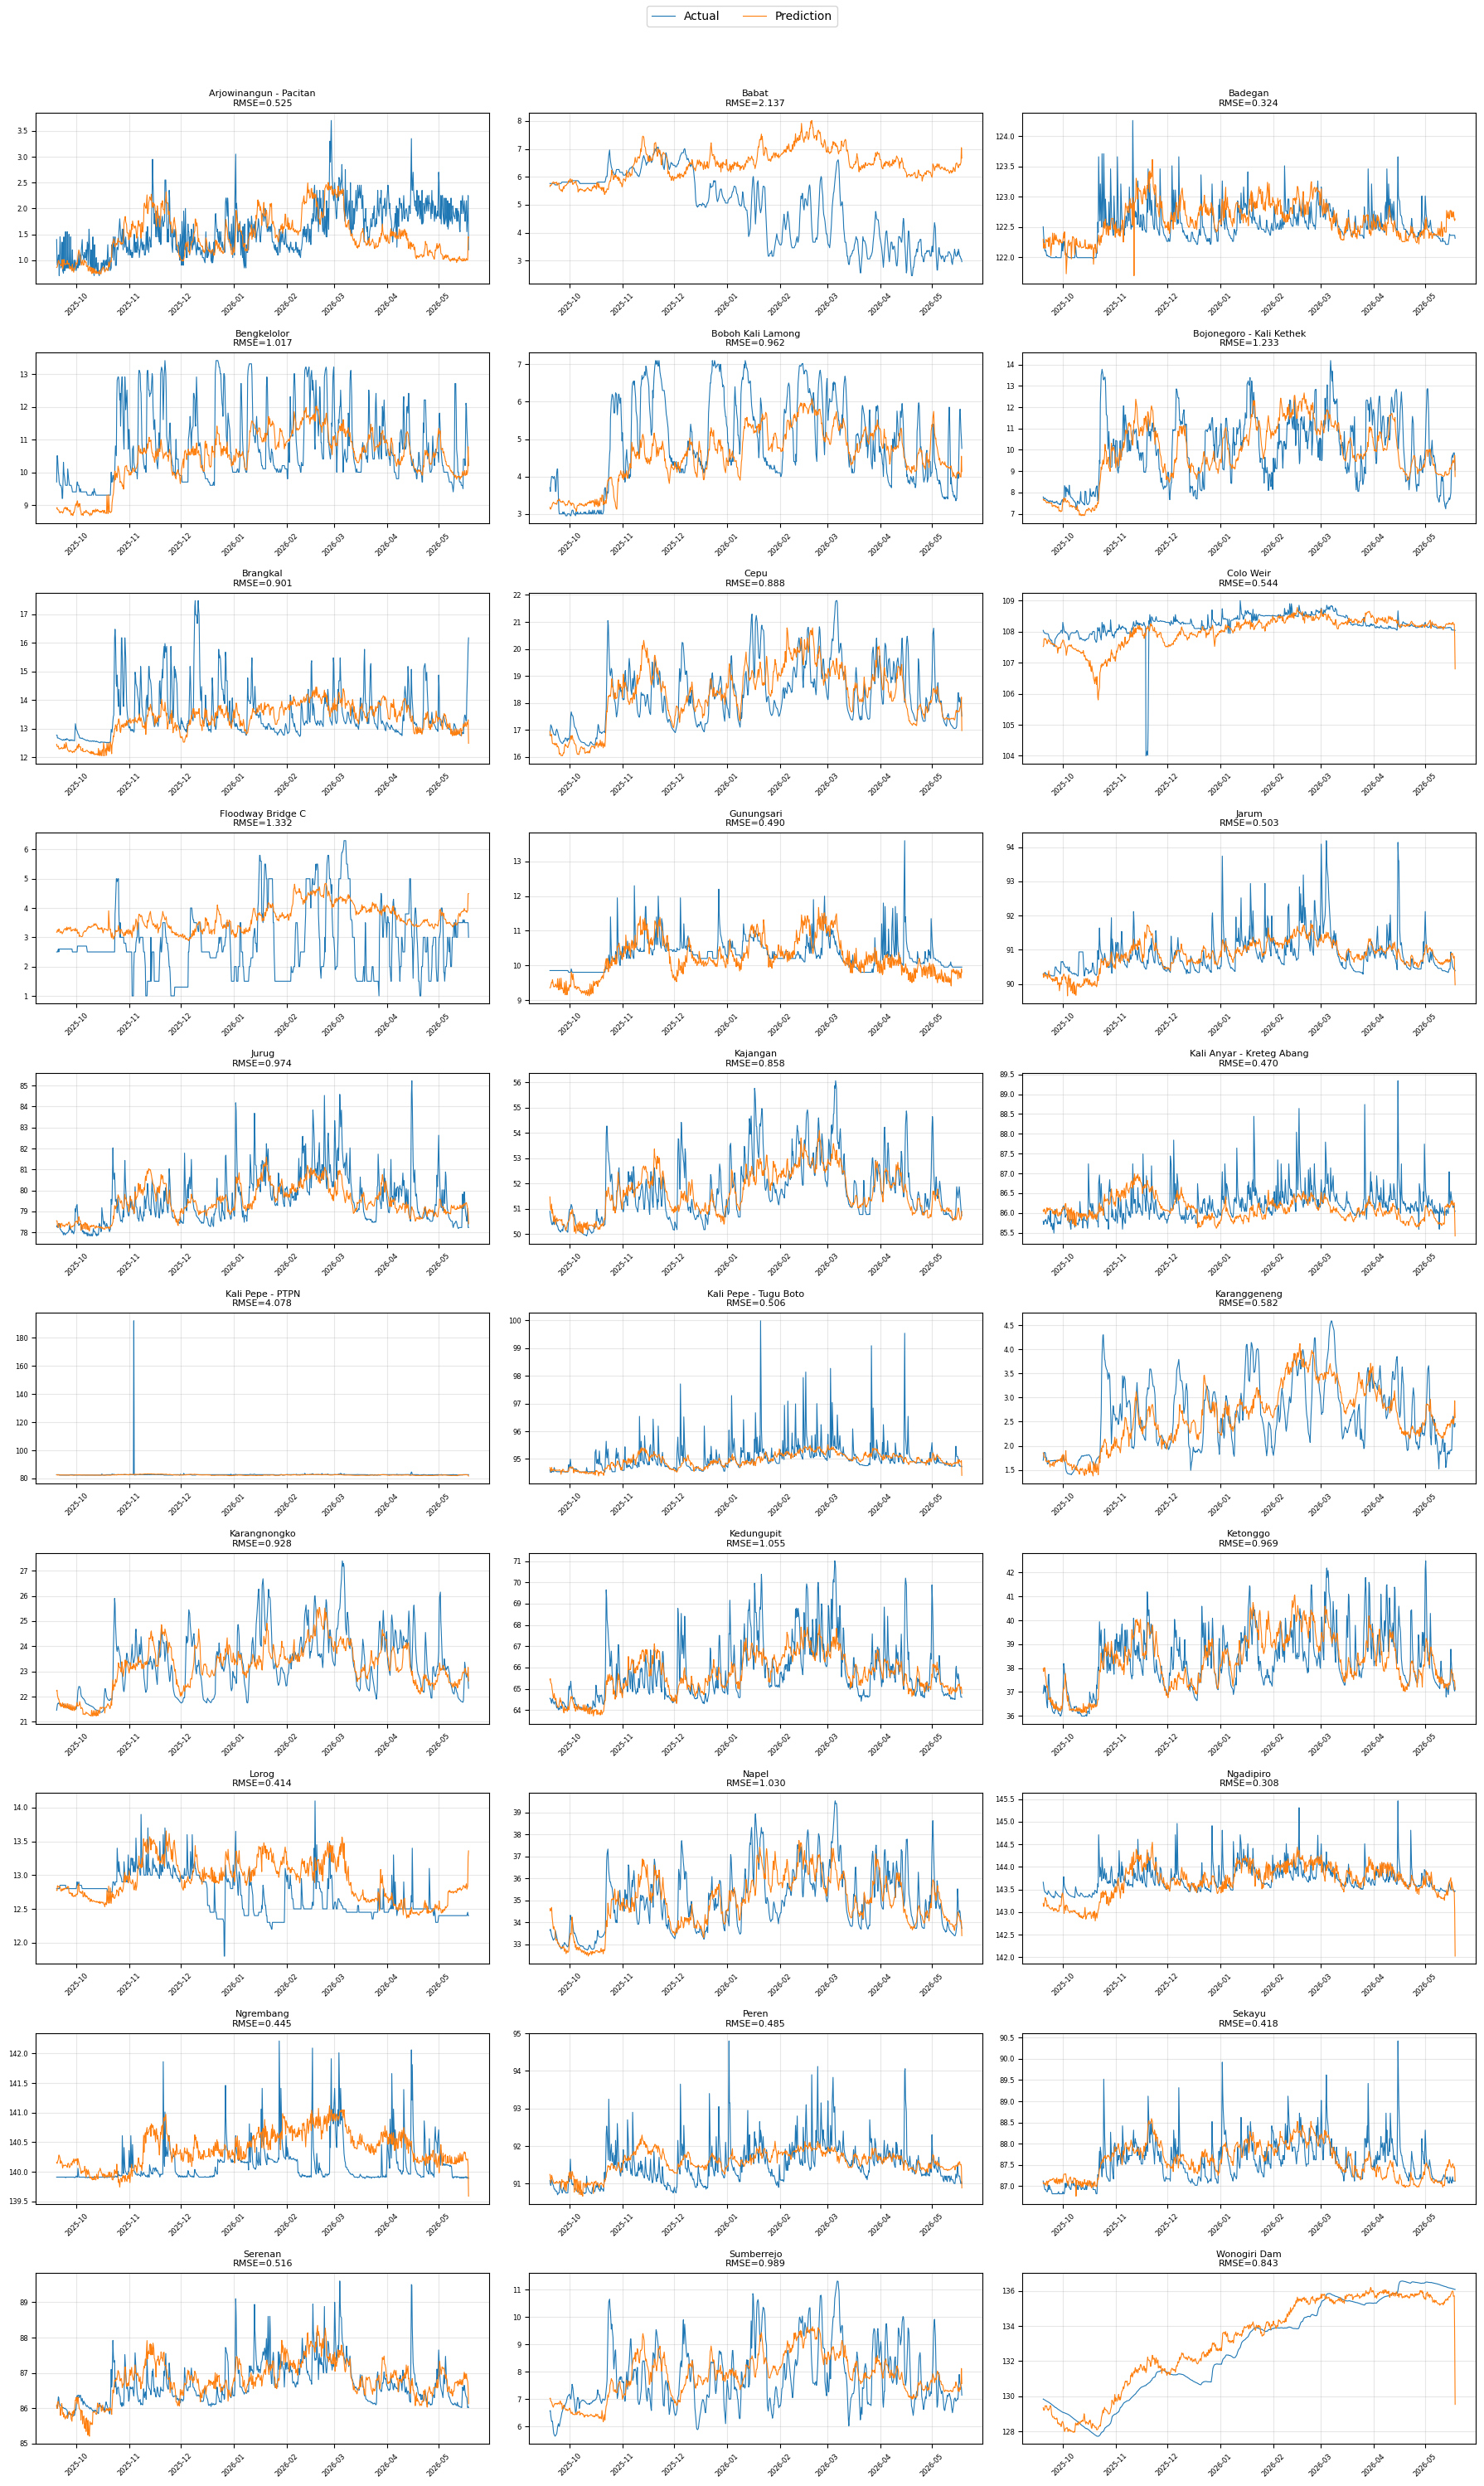

In [59]:
# ==========================================================
# Simpan hasil prediksi ke val_set
# ==========================================================

val_plot = val_set.copy()

val_plot["pred"] = pred_val_cat
val_plot["error"] = val_plot["pred"] - val_plot["tma_mdpl"]

# ==========================================================
# Pastikan hanya periode validasi
# ==========================================================

start_date = pd.Timestamp("2025-09-19")
end_date   = pd.Timestamp("2026-05-18 23:59:59")

val_plot = val_plot[
    (val_plot["datetime"] >= start_date) &
    (val_plot["datetime"] <= end_date)
].copy()

print(val_plot["datetime"].min())
print(val_plot["datetime"].max())

# ==========================================================
# Plot
# ==========================================================

stations = sorted(val_plot["nama_pos"].unique())

ncols = 3
nrows = math.ceil(len(stations) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 3*nrows)
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    df = (
        val_plot[val_plot["nama_pos"] == station]
        .sort_values("datetime")
    )

    rmse = np.sqrt(
        np.mean(
            (df["pred"] - df["tma_mdpl"])**2
        )
    )

    ax.plot(
        df["datetime"],
        df["tma_mdpl"],
        label="Actual",
        linewidth=0.8
    )

    ax.plot(
        df["datetime"],
        df["pred"],
        label="Prediction",
        linewidth=0.8
    )

    ax.set_title(
        f"{station}\nRMSE={rmse:.3f}",
        fontsize=8
    )

    ax.tick_params(
        axis="x",
        rotation=45,
        labelsize=6
    )

    ax.tick_params(
        axis="y",
        labelsize=6
    )

    ax.grid(alpha=0.3)

for j in range(len(stations), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

plt.tight_layout(rect=[0,0,1,0.97])

plt.show()

In [60]:
val_set = val_set.copy()
val_set['pred'] = cat.predict(val_set[feature_cols])  # ganti 'cat' sesuai model kamu

# RMSE per pos + NRMSE (dinormalisasi thd rentang tma pos itu sendiri, biar ADIL lintas skala)
per_pos = val_set.groupby('nama_pos').apply(
    lambda d: pd.Series({
        'rmse': np.sqrt(mean_squared_error(d['tma_mdpl'], d['pred'])),
        'tma_range': train_set[train_set['nama_pos']==d.name]['tma_mdpl'].max() - train_set[train_set['nama_pos']==d.name]['tma_mdpl'].min(),
        'n_baris': len(d),
    })
).reset_index()
per_pos['nrmse_pct'] = (per_pos['rmse'] / per_pos['tma_range']) * 100
per_pos = per_pos.sort_values('nrmse_pct', ascending=False)

print('=== 10 pos TERBURUK (NRMSE %, adil lintas skala) ===')
print(per_pos.head(10).to_string(index=False))
print()
print('=== 10 pos TERBAIK ===')
print(per_pos.tail(10).to_string(index=False))

=== 10 pos TERBURUK (NRMSE %, adil lintas skala) ===
              nama_pos     rmse  tma_range  n_baris  nrmse_pct
      Kali Pepe - PTPN 4.078148   4.305995    726.0  94.708627
                 Babat 2.137164   5.250000    726.0  40.707891
     Floodway Bridge C 1.331678   5.960203    726.0  22.342827
                 Lorog 0.413518   2.350000    726.0  17.596498
     Boboh Kali Lamong 0.961854   5.500000    726.0  17.488255
           Bengkelolor 1.016941   5.934234    726.0  17.136854
               Badegan 0.323624   2.057899    726.0  15.725942
            Sumberrejo 0.989026   7.626947    726.0  12.967524
              Brangkal 0.900644   7.348157    726.0  12.256729
Arjowinangun - Pacitan 0.524975   4.502361    726.0  11.659986

=== 10 pos TERBAIK ===
                 nama_pos     rmse  tma_range  n_baris  nrmse_pct
                    Jarum 0.502771   5.150328    726.0   9.761916
    Kali Pepe - Tugu Boto 0.506095   5.279334    726.0   9.586333
                  Serenan 0.5161

C:\Users\leouw\AppData\Local\Temp\ipykernel_5084\3487094808.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pos = val_set.groupby('nama_pos').apply(


In [61]:
per_pos['total_se'] = per_pos['rmse']**2 * per_pos['n_baris']
per_pos['pct_of_total_se'] = per_pos['total_se'] / per_pos['total_se'].sum() * 100
per_pos_by_impact = per_pos.sort_values('total_se', ascending=False)

print('=== Ranking berdasar KONTRIBUSI ke skor leaderboard ===')
print(per_pos_by_impact[['nama_pos','rmse','n_baris','total_se','pct_of_total_se']].head(10).to_string(index=False))
print(f'\n10 pos teratas ini menyumbang: {per_pos_by_impact.head(10)["pct_of_total_se"].sum():.1f}% dari total error')

=== Ranking berdasar KONTRIBUSI ke skor leaderboard ===
                nama_pos     rmse  n_baris     total_se  pct_of_total_se
        Kali Pepe - PTPN 4.078148    726.0 12074.319844        43.173388
                   Babat 2.137164    726.0  3315.984093        11.856756
       Floodway Bridge C 1.331678    726.0  1287.463684         4.603503
Bojonegoro - Kali Kethek 1.232554    726.0  1102.931200         3.943682
              Kedungupit 1.054921    726.0   807.935837         2.888885
                   Napel 1.029616    726.0   769.639353         2.751951
             Bengkelolor 1.016941    726.0   750.806773         2.684613
              Sumberrejo 0.989026    726.0   710.153414         2.539251
                   Jurug 0.973669    726.0   688.270076         2.461004
                Ketonggo 0.968858    726.0   681.485776         2.436746

10 pos teratas ini menyumbang: 79.3% dari total error


In [62]:
# Sample weight
sample_weight_tr = np.where(train['musim_hujan'] == 1, 2.4, 1.0)

# Train model
cat_final = CatBoostRegressor(**cat_params)
cat_final.fit(
    train[feature_cols],
    train['tma_mdpl'],
    sample_weight=sample_weight_tr
)

# Predict
test_pred = cat_final.predict(test[feature_cols])

# Load sample submission
sample_sub = pd.read_csv("../data/sample_submission.csv")

# Pastikan jumlah prediksi sesuai
assert len(test_pred) == len(sample_sub), \
    f"Jumlah prediksi ({len(test_pred)}) != sample submission ({len(sample_sub)})"

# Isi kolom target
sample_sub["tma_mdpl"] = test_pred

# Simpan
sample_sub.to_csv("outputs/submission_cat.csv", index=False)

print(sample_sub.head())

                                             id  tma_mdpl
0  2025-09-19 06:00:00 - Arjowinangun - Pacitan  0.860063
1  2025-09-19 12:00:00 - Arjowinangun - Pacitan  0.865357
2  2025-09-19 18:00:00 - Arjowinangun - Pacitan  0.887771
3  2025-09-20 06:00:00 - Arjowinangun - Pacitan  0.993799
4  2025-09-20 12:00:00 - Arjowinangun - Pacitan  0.993963
